# Every anomaly in this dataset was the same bug

**Cleveland Heart Disease data — 303 patients referred for diagnostic workup, 13
measurements and a diagnosis.**

I wrote my first pass through this dataset as a *medical translation guide*: before
analysing a column I wanted to know what it measures, why a cardiologist would order it,
and which direction counts as bad. That turned out to be the most useful thing I did,
because it gave me an expectation for every column — and expectations are what let you
notice when something is wrong.

Five things came out wrong, and I flagged each one in capital letters and moved on:

- 104 patients with the chest-pain type most suggestive of disease were labelled healthy.
  *"THIS IS SUSPICIOUS!"*
- `ca = 0` — no blocked vessels on angiography — contained 130 diseased against 45
  healthy patients, the opposite of what it should. *"The data is highly suspicious
  here."*
- Patients labelled diseased were **younger**, with **lower** blood pressure, **lower**
  cholesterol, **less** ST depression and **higher** maximum heart rate than the healthy
  ones. Every sign backwards.
- Every stress-test correlation had the wrong sign.
- More women than men had heart disease, contradicting the entire epidemiological
  literature.

I concluded that the target labels were probably reversed, then talked myself out of
acting on it because the categorical columns "made good sense". That was the right
instinct and the wrong resolution.

**This notebook resolves all five at once.** The UCI repository publishes the original
Cleveland file, and this project folder already contains it. Joining the two tables on
the columns that were *not* re-encoded recovers an exact, deterministic mapping for 301
of 303 patients — and it shows that whoever produced the CSV I had been working with
**reversed the code order of every ordinal column and flipped the target**.

`target = 1` does not mean disease. It means **no** disease. `cp = 0` is not typical
angina, it is asymptomatic. `slope = 0` is not upsloping, it is downsloping. `ca = 4`
is not four blocked vessels, it is a missing value. Once the file is decoded, every one
of my five anomalies disappears and the data becomes textbook cardiology.

**Data sources.**
[Heart Disease, UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/45/heart+disease)
(Detrano et al., 1989; donated by David Aha, CC BY 4.0) — the authoritative original.
The 303-row `heart.csv` analysed here is the widely circulated Kaggle redistribution of
the same patients.

> **This is a referral population.** Every patient was sent for a diagnostic workup
> because someone already suspected heart disease. Nothing in this notebook describes
> the general population, and no rate here is a population prevalence.

---
## 1. Setup

The split that runs through the whole notebook is **disease** against **no disease**, and
those two keep one colour each in every chart.

My first pass used green for healthy and red for diseased, which is the natural choice
and unfortunately the single worst pair for colourblind readers — red and green collapse
towards the same hue under both deuteranopia and protanopia, and these two had a
lightness ratio of only 1.28, so they were also near-identical in greyscale. I kept the
intent (cool = healthy, warm = diseased) and moved to a **teal / terracotta** pair, which
tests at a lightness ratio of 1.87 and stays clearly separated under both simulations.

There is one deliberate twist. Until section 7, nobody knows what `target = 1` means — it
is an uninterpreted code, not a diagnosis. Colouring it teal would be claiming knowledge
the notebook has not established yet, and worse, those patients turn out to be the
*diseased* ones, so they would silently swap colour halfway through. **So every chart
before the decoding is drawn in two greys, and the clinical palette only appears once the
labels have been earned.** If a category is teal in one chart it is teal in every chart
after it.

A third grey is used for context — series present to be compared against rather than read
individually. The sequential ramp appears once, for disease rate across categories, and
the diverging ramp once, for correlations centred on zero.

In [1]:
import io
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

import plotly.graph_objects as go
import plotly.io as pio

# Pulls plotly.js from a CDN instead of embedding it: keeps the committed .ipynb small
# and the charts stay interactive on Kaggle.
pio.renderers.default = "notebook_connected"

RANDOM_SEED = 7
rng = np.random.default_rng(RANDOM_SEED)

FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(exist_ok=True)


def find_file(*names):
    """Locate a data file next to the notebook or in Kaggle's input directory."""
    for name in names:
        candidates = [Path(name)]
        candidates += list(Path("/kaggle/input").glob("*/" + name))
        candidates += list(Path("/kaggle/input").glob("*/*/" + name))
        for candidate in candidates:
            if candidate.exists():
                return candidate
    return None


# ---------------------------------------------------------------- palette ----
# Declared once. A class keeps its colour for the entire notebook.
C = {
    "no_disease": "#0F7173",   # teal
    "disease":    "#E2725B",   # terracotta
    "code_0":     "#9AA0A6",   # uninterpreted target = 0, before section 7
    "code_1":     "#4A4E52",   # uninterpreted target = 1, before section 7
    "neutral":    "#9AA0A6",   # context, un-highlighted series
    "accent":     "#C8553D",   # the one thing a chart is about
    "boundary":   "#2B2B2B",
    "text":       "#2B2B2B",
    "grid":       "#DDDDDD",
    "panel":      "#F4F1EC",   # legend panel background
}

# Before section 7 the target is an uninterpreted code, so it is drawn in greys.
RAW_COLOR = {0: C["code_0"], 1: C["code_1"]}
RAW_LABEL = {0: "target = 0", 1: "target = 1"}

# After section 7 it is a diagnosis, and earns the clinical palette.
DISEASE_COLOR = {0: C["no_disease"], 1: C["disease"]}
DISEASE_LABEL = {0: "No disease", 1: "Disease"}

# Sequential: disease rate across categories, low to high.
SEQ = LinearSegmentedColormap.from_list("seq", ["#F3F6F6", C["disease"]])
# Diverging: correlations, centred on zero.
DIV = LinearSegmentedColormap.from_list("div", [C["no_disease"], "#F5F2EF", C["disease"]])

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "axes.grid": True,
    "axes.grid.axis": "y",
    "axes.axisbelow": True,          # gridlines behind the data, never through it
    "grid.color": C["grid"],
    "grid.linewidth": 0.7,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#BBBBBB",
    "axes.titlesize": 13,
    "axes.titleweight": "semibold",
    "axes.titlelocation": "left",
    "axes.labelcolor": C["text"],
    "text.color": C["text"],
    "font.size": 11,
})

PLOTLY_LAYOUT = dict(
    template="simple_white",
    font=dict(size=13, color=C["text"]),
    title_x=0.02,
    title_xanchor="left",
    title_font=dict(size=16),
    margin=dict(l=70, r=40, t=95, b=60),
)


def titled(ax, title, subtitle=None):
    """Bold left-aligned title with an optional grey subtitle underneath it.

    matplotlib has no subtitle, and placing one with ax.text collides with the title
    unless the title is padded first. Doing it in one place keeps every chart aligned.
    """
    ax.set_title(title, pad=26 if subtitle else 12)
    if subtitle:
        ax.text(0, 1.015, subtitle, transform=ax.transAxes,
                fontsize=9.5, color="#666666", va="bottom")

In [2]:
heart_path = find_file("heart.csv")
df = pd.read_csv(heart_path)

BINARY_COLUMNS = ["sex", "fbs", "exang", "target"]
CATEGORICAL_COLUMNS = ["cp", "restecg", "slope", "ca", "thal"]
CONTINUOUS_COLUMNS = ["age", "trestbps", "chol", "thalach", "oldpeak"]

TITLES = {
    "age": "Age",
    "trestbps": "Resting Blood Pressure",
    "chol": "Serum Cholesterol",
    "thalach": "Maximum Heart Rate",
    "oldpeak": "ST Depression",
}
XLABELS = {
    "age": "age (years)",
    "trestbps": "trestbps (mm Hg)",
    "chol": "chol (mg/dL)",
    "thalach": "thalach (beats/min)",
    "oldpeak": "oldpeak (mm)",
}

print(f"{df.shape[0]} patients x {df.shape[1] - 1} features + 1 target")
print(f"\nMissing values of type NaN: {df.isna().sum().sum()}")
print(f"Exactly duplicated rows:     {df.duplicated().sum()}")
df.head()

303 patients x 13 features + 1 target

Missing values of type NaN: 0
Exactly duplicated rows:     1


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


---
## 2. The medical translation guide

This is the part of my first pass I would keep unchanged. Before looking at a single
distribution I worked out what each column is actually measuring, because a column you
cannot interpret is a column you cannot sanity-check.

The thirteen measurements fall into four groups, and the grouping is the point: they are
not thirteen independent risk factors, they are four different *kinds* of evidence about
one disease.

**The mechanism — how the disease forms**

- `trestbps` (resting blood pressure) — high pressure physically damages the artery
  walls, which makes plaque more likely to lodge there.
- `chol` (serum cholesterol) — the raw material of the plaque itself.
- `fbs` (fasting blood sugar > 120 mg/dL) — a metabolic risk factor; diabetes accelerates
  the whole process.

**The symptom — what the patient feels**

- `cp` (chest pain type) — the heart muscle's distress signal when it is not getting
  enough oxygen.

**The stress test — make the heart work hard and watch it fail**

- `thalach` (maximum heart rate achieved), `exang` (angina brought on by the test),
  `oldpeak` (ST depression under exercise) and `slope` (the shape of that ST segment at
  peak exercise). The logic is to raise oxygen demand until a narrowed artery cannot keep
  up, then record what happens.

**The direct look — imaging the disease itself**

- `ca` — the number of major vessels lit up by fluoroscopy with dye injected into the
  coronaries. This is the plaque, directly imaged.
- `thal` (thallium scan) — whether heart muscle is alive but starved (a *reversible*
  defect, which is what active disease looks like) or already dead (a *fixed* defect,
  meaning a prior heart attack).
- `restecg` — electrical evidence of pre-existing damage.

**The two you cannot change** — `age` and `sex`.

A note that matters for every conclusion below: **`ca` and `thal` are not risk factors,
they are diagnostics.** In clinical practice nobody orders an invasive angiogram unless
they already suspect disease, and the angiogram is close to the definition of the
diagnosis rather than a predictor of it. Any model that uses `ca` to "predict" `target`
is mostly rediscovering how the label was made.

---
## 3. Are the continuous measurements physiologically possible?

There are no `NaN` values in this file, which does not mean there is nothing missing —
only that nothing is missing in a form pandas recognises. Section 7 finds the missing
values hiding in plain sight.

For the five continuous columns the first question is whether the ranges are
survivable. I built a reference table for each one from clinical reference ranges, then
checked the observed minimum and maximum against it.

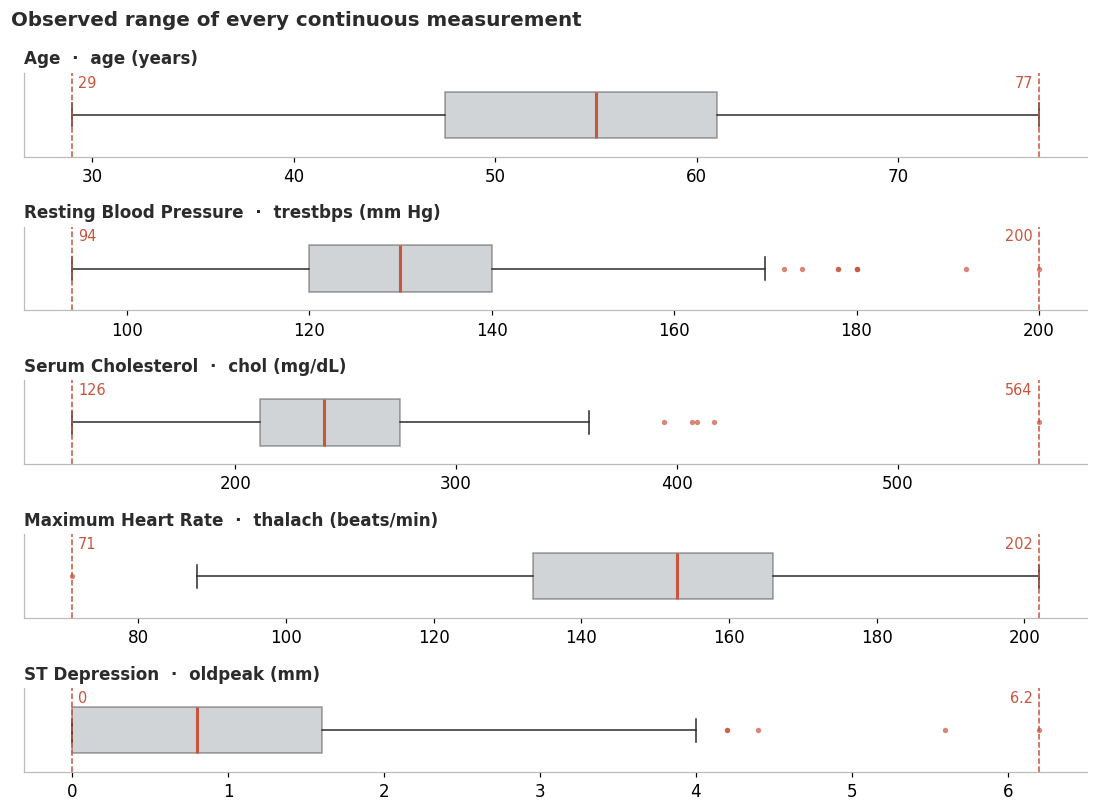

In [3]:
fig, axes = plt.subplots(len(CONTINUOUS_COLUMNS), 1, figsize=(10, 7.5))

for ax, column in zip(axes, CONTINUOUS_COLUMNS):
    data = df[column].dropna()

    ax.boxplot(data, vert=False, widths=0.55,
               patch_artist=True,
               boxprops=dict(facecolor=C["neutral"], alpha=0.45, edgecolor=C["boundary"]),
               medianprops=dict(color=C["accent"], linewidth=2),
               flierprops=dict(marker="o", markersize=3.5,
                               markerfacecolor=C["accent"], markeredgecolor="none",
                               alpha=0.7),
               whiskerprops=dict(color=C["boundary"]),
               capprops=dict(color=C["boundary"]))

    low, high = data.min(), data.max()
    # Labelled inside the axes rather than under them: below the axis they collide with
    # the tick labels, which is how the first version of this figure printed 29 over 30.
    for value, align, nudge in ((low, "left", 4), (high, "right", -4)):
        ax.axvline(value, color=C["accent"], linestyle="--", linewidth=1)
        ax.annotate(f"{value:g}", xy=(value, 0.88), xycoords=ax.get_xaxis_transform(),
                    xytext=(nudge, 0), textcoords="offset points",
                    color=C["accent"], ha=align, va="center", fontsize=9.5)

    ax.set_title(f"{TITLES[column]}  ·  {XLABELS[column]}", fontsize=11)
    ax.set_yticks([])
    ax.grid(axis="x", visible=False)

fig.suptitle("Observed range of every continuous measurement",
             x=0.005, ha="left", fontsize=13, fontweight="semibold")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "01-continuous-ranges.png")
plt.show()

**Reference ranges, and what the observed values do against them**

`age` — 29 to 77. Adults only; no children or adolescents in this cohort.

`trestbps`, resting systolic blood pressure in mm Hg:

| trestbps | Interpretation |
| ---: | --- |
| < 90 | low |
| 90–119 | normal |
| 120–129 | elevated |
| 130–139 | high |
| 140–179 | hypertension |
| ≥ 180 | severely high |

Observed 94–200, which is a plausible clinical range. **Fine.**

`chol`, serum cholesterol in mg/dL:

| chol | Interpretation |
| ---: | --- |
| < 200 | desirable |
| 200–239 | borderline high |
| 240–299 | high |
| 300–399 | very high, still plausible |
| 400–499 | extremely high, uncommon but possible |
| ≥ 500 | very unusual |

Observed 126–564. The maximum sits in the "very unusual" band — **flagged for section 4.**

`thalach`, maximum heart rate achieved during the exercise test, in bpm:

| thalach | Interpretation |
| ---: | --- |
| < 50 | very unusual |
| 50–100 | low but possible |
| 100–150 | common |
| 150–200 | common during exercise testing |
| 200–220 | high but possible |
| > 220 | very unusual |

Observed 71–202. **Fine.**

`oldpeak`, exercise-induced ST depression relative to rest, in mm:

| oldpeak | Interpretation |
| ---: | --- |
| 0–1 | common |
| 1–2 | common |
| 2–4 | high but plausible |
| 4–6 | very high, uncommon but possible |
| > 6 | extremely unusual |

Observed 0.0–6.2. The maximum is just past the edge — **flagged for section 4.**

---
## 4. The two extreme values

Two measurements sit outside their reference bands: one cholesterol of 564 mg/dL and one
ST depression of 6.2 mm. In my first pass I plotted them together, called them
*"physiologically impossible"* and deleted both rows.

The plot was the right move. The deletion was not, and it is worth being precise about
why, because "remove the outliers" is the most over-applied step in exploratory analysis.

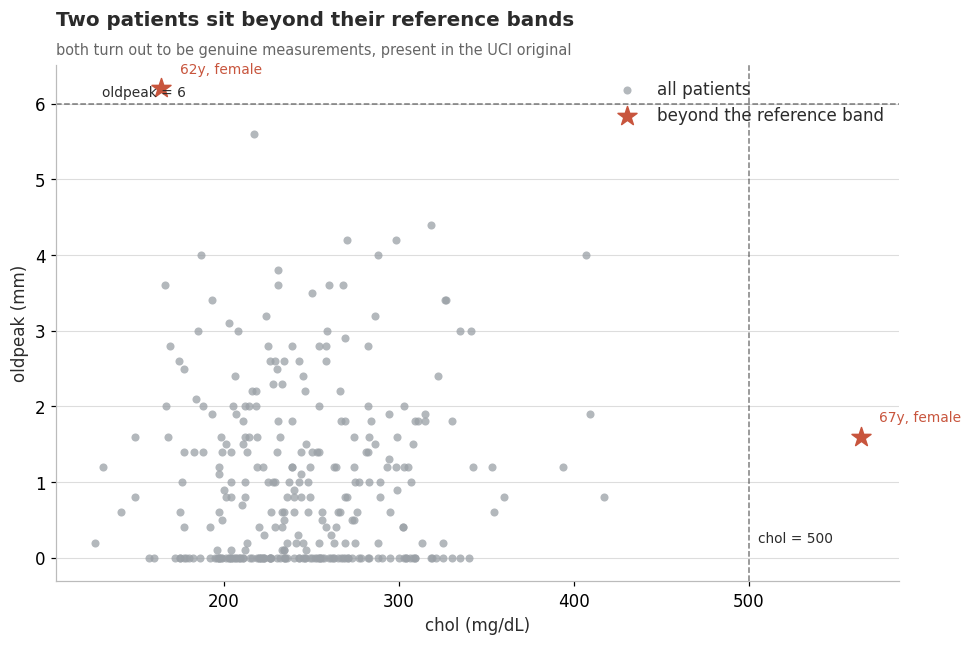

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
85,67,0,2,115,564,0,0,160,0,1.6,1,0,3,1
204,62,0,0,160,164,0,0,145,0,6.2,0,3,3,0


In [4]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(df["chol"], df["oldpeak"],
           color=C["neutral"], alpha=0.75, s=28, linewidths=0, label="all patients")

extreme_oldpeak = df["oldpeak"] > 6
extreme_chol = df["chol"] > 500
extreme = extreme_oldpeak | extreme_chol

ax.scatter(df.loc[extreme, "chol"], df.loc[extreme, "oldpeak"],
           color=C["accent"], s=170, marker="*", zorder=3, label="beyond the reference band")

ax.axvline(500, color=C["boundary"], linestyle="--", alpha=0.6, linewidth=1)
ax.axhline(6, color=C["boundary"], linestyle="--", alpha=0.6, linewidth=1)
ax.text(505, 0.2, "chol = 500", fontsize=9, color=C["boundary"])
ax.text(130, 6.1, "oldpeak = 6", fontsize=9, color=C["boundary"])

for _, row in df.loc[extreme].iterrows():
    ax.annotate(f"{row['age']:.0f}y, "
                f"{'male' if row['sex'] == 1 else 'female'}",
                xy=(row["chol"], row["oldpeak"]),
                xytext=(12, 10), textcoords="offset points",
                fontsize=9, color=C["accent"])

ax.set_xlabel("chol (mg/dL)")
ax.set_ylabel("oldpeak (mm)")
titled(ax, "Two patients sit beyond their reference bands",
       "both turn out to be genuine measurements, present in the UCI original")
ax.legend(frameon=False, loc="upper right")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "02-extreme-values.png")
plt.show()

display(df.loc[extreme])

### Are they errors, or are they patients?

The test is available and decisive: both rows should appear in the UCI original. A
transcription error would not survive a round trip through a different file.

In [5]:
uci_path = find_file("processed.cleveland.data")

UCI_COLUMNS = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
               "thalach", "exang", "oldpeak", "slope", "ca", "thal", "num"]
uci = pd.read_csv(uci_path, header=None, names=UCI_COLUMNS, na_values="?")

print(f"UCI original: {uci.shape[0]} patients\n")
print(f"chol > 500 in the UCI file:    {(uci['chol'] > 500).sum()}")
print(uci.loc[uci["chol"] > 500, ["age", "sex", "chol", "num"]].to_string(index=False))
print(f"\noldpeak > 6 in the UCI file:   {(uci['oldpeak'] > 6).sum()}")
print(uci.loc[uci["oldpeak"] > 6, ["age", "sex", "oldpeak", "num"]].to_string(index=False))
print(f"\nchol recorded as 0 (the usual Cleveland data error): {(uci['chol'] == 0).sum()}")

UCI original: 303 patients

chol > 500 in the UCI file:    1
 age  sex  chol  num
67.0  0.0 564.0    0

oldpeak > 6 in the UCI file:   1
 age  sex  oldpeak  num
62.0  0.0      6.2    3

chol recorded as 0 (the usual Cleveland data error): 0


**Takeaway — I was wrong to delete these, and I am keeping them.**

Both values are in the UCI original exactly as they appear here. They are real
measurements from real patients: a 67-year-old woman with a cholesterol of 564 mg/dL,
which is severe familial hypercholesterolaemia and entirely survivable, and a 62-year-old
woman with 6.2 mm of ST depression, which is profound ischaemia and precisely the kind of
patient this dataset exists to study.

The distinction I had blurred is between **implausible** and **extreme**. An
implausible value is one the world cannot produce — a negative blood pressure, a
cholesterol of 0 where the measurement failed. Cleveland has none of the latter, though
the Switzerland subset of the same study is full of them. An extreme value is one the
world produces rarely, and deleting those systematically removes the most informative
patients in the file.

So: both rows stay, and the notebook flags them rather than dropping them. This reverses
the decision in my first pass, where I removed 2 of 303 patients — including, as it
happens, one of the most severely ischaemic people in the cohort.

---
## 5. The categorical features, and two that made no sense

Now the part that generated all the trouble. For each categorical column I wrote down
what the codes are supposed to mean and what I therefore expected to see, then plotted
the counts by target.

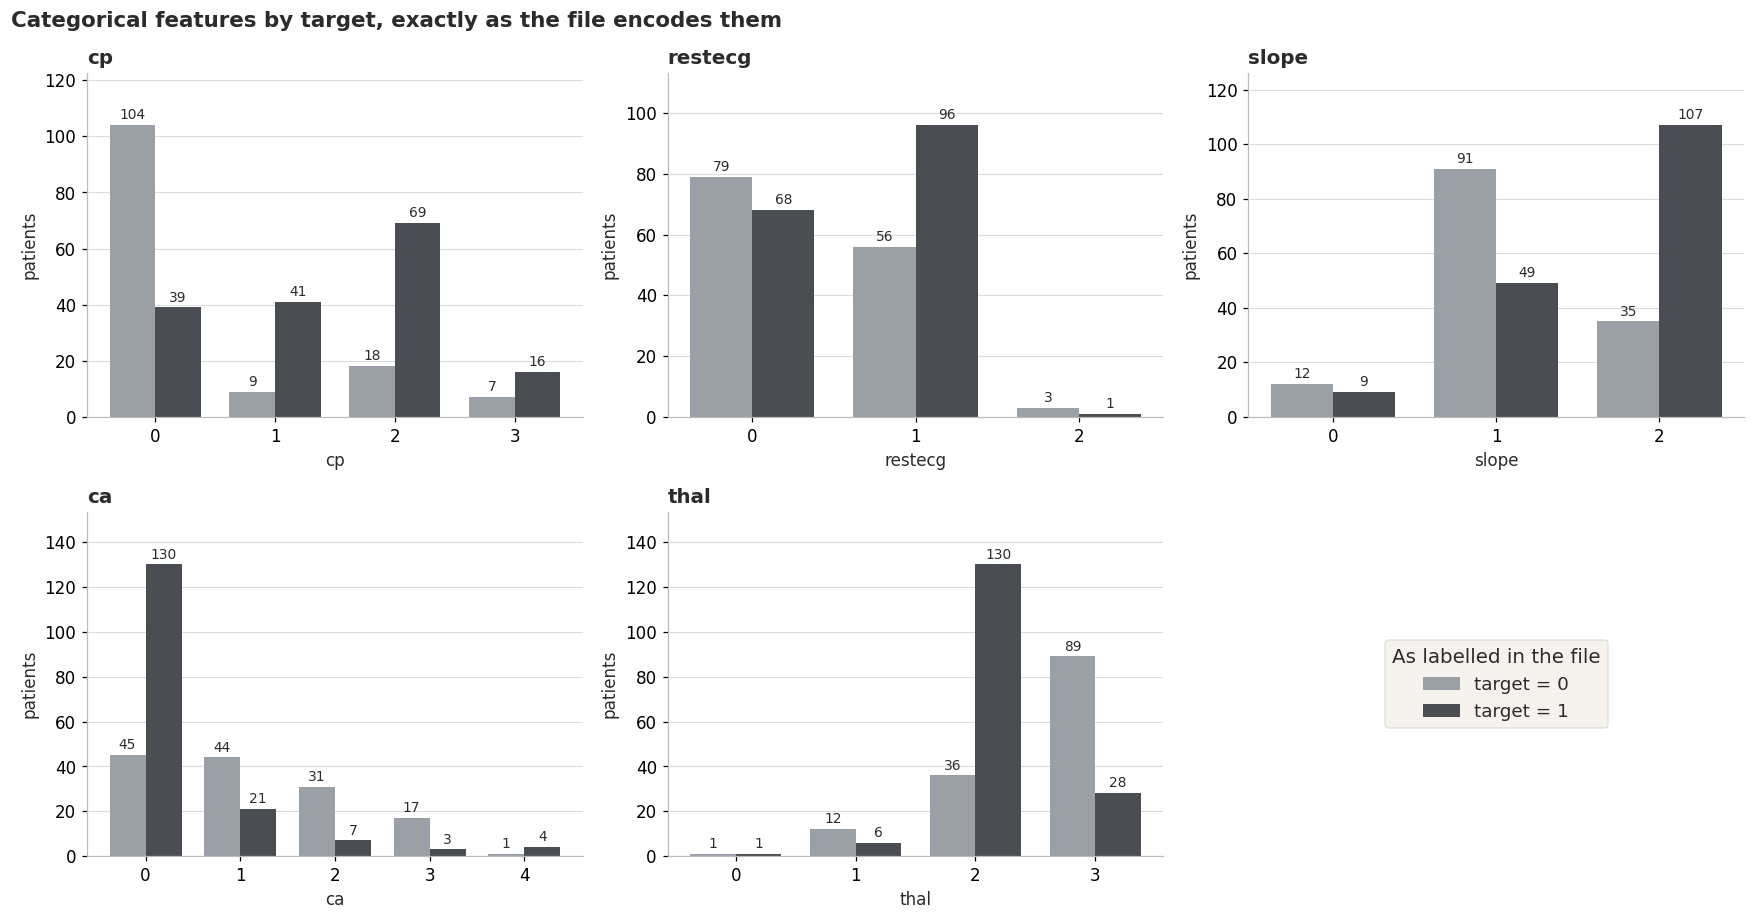

In [6]:
def category_counts(frame, column, target="target"):
    """Counts of each category, split by target, with every category present in both."""
    categories = sorted(frame[column].unique())
    counts = {}
    for value in (0, 1):
        subset = frame.loc[frame[target] == value, column].value_counts()
        counts[value] = [subset.get(category, 0) for category in categories]
    return categories, counts[0], counts[1]


fig, axes = plt.subplots(2, 3, figsize=(16, 8.5))
axes = axes.flatten()

for ax, column in zip(axes[:-1], CATEGORICAL_COLUMNS):
    categories, values_0, values_1 = category_counts(df, column)
    x = np.arange(len(categories))
    width = 0.38

    bars_0 = ax.bar(x - width / 2, values_0, width,
                    color=RAW_COLOR[0], label="target = 0")
    bars_1 = ax.bar(x + width / 2, values_1, width,
                    color=RAW_COLOR[1], label="target = 1")

    ax.bar_label(bars_0, padding=2, fontsize=9)
    ax.bar_label(bars_1, padding=2, fontsize=9)

    ax.set_xticks(x, categories)
    ax.set_xlabel(column)
    ax.set_ylabel("patients")
    ax.set_title(f"{column}")
    ax.set_ylim(0, max(values_0 + values_1) * 1.18)
    ax.grid(axis="x", visible=False)

axes[-1].axis("off")
axes[-1].legend(
    handles=[Patch(facecolor=RAW_COLOR[0]), Patch(facecolor=RAW_COLOR[1])],
    labels=["target = 0", "target = 1"],
    loc="center", fontsize=12, frameon=True, edgecolor=C["grid"],
    facecolor=C["panel"], title="As labelled in the file", title_fontsize=13,
)

fig.suptitle("Categorical features by target, exactly as the file encodes them",
             x=0.005, ha="left", fontsize=14, fontweight="semibold")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "03-categoricals-raw.png")
plt.show()

### What I expected, column by column

I take the code meanings below from the dataset descriptions that circulate with this
CSV. Every one of them turns out to be wrong, but that is the point of the section — this
is the state I was reasoning from.

**`cp` — chest pain type.** Documented as `0` = typical angina, `1` = atypical angina,
`2` = non-anginal pain, `3` = asymptomatic. Typical angina is the classic presentation of
coronary disease, so `cp = 0` should be heavily weighted towards disease.

> **Observed:** `cp = 0` holds 104 patients at `target = 0` against only 39 at
> `target = 1`. The code that should be the sickest looks like the healthiest.
> **THIS IS SUSPICIOUS.**

**`ca` — major vessels coloured by fluoroscopy.** `0` through `3`, counting blocked
vessels. More vessels means more disease; this is close to the definition of the
diagnosis, so it is the column I trust most.

> **Observed:** `ca = 0` — *no* blocked vessels — holds 130 patients at `target = 1`
> against 45 at `target = 0`, and the rate falls steadily as vessels are added. Exactly
> backwards. And `ca = 4` exists at all, which the documentation does not allow.
> **HIGHLY SUSPICIOUS.**

**`restecg` — resting ECG.** Documented as `0` = normal, `1` = ST-T wave abnormality,
`2` = left ventricular hypertrophy. I expected `restecg = 0` to be commoner among the
healthy.

> **Observed:** 79 against 68 at `restecg = 0`, tilting the right way; `restecg = 1`
> tilts towards `target = 1`. **Looks fine.**

**`slope` — ST segment slope at peak exercise.** Documented as `0` = upsloping,
`1` = flat, `2` = downsloping. Downsloping is the classic ischaemia sign, so `slope = 2`
should be the sickest group.

> **Observed:** `slope = 2` holds 107 at `target = 1` against 35 at `target = 0` — the
> sickest group in the column, just as predicted. **Looks fine.**

**`thal` — thallium scan.** Documented as `0` = normal, `1` = fixed defect,
`2` = reversible defect, `3` = not described. A reversible defect is live but starved
muscle, the exact thing active coronary disease produces.

> **Observed:** `thal = 2` holds 130 at `target = 1` against 36 at `target = 0` — the
> reversible-defect code is the sickest, as expected. **Looks fine.**

So: two columns badly wrong, three columns apparently fine. **This split is what stopped
me**, and section 7 explains why it is the most misleading possible result. For now, note
that the two columns screaming loudest are `cp` and `ca` — and `ca` is the one closest to
being the diagnosis itself.

---
## 6. The continuous features disagree too

Here I plotted each continuous feature's distribution by target, with histograms
underneath the KDE curves because a KDE alone over-smooths and hides the shape of small
samples, and with the group means marked so they could be compared directly.

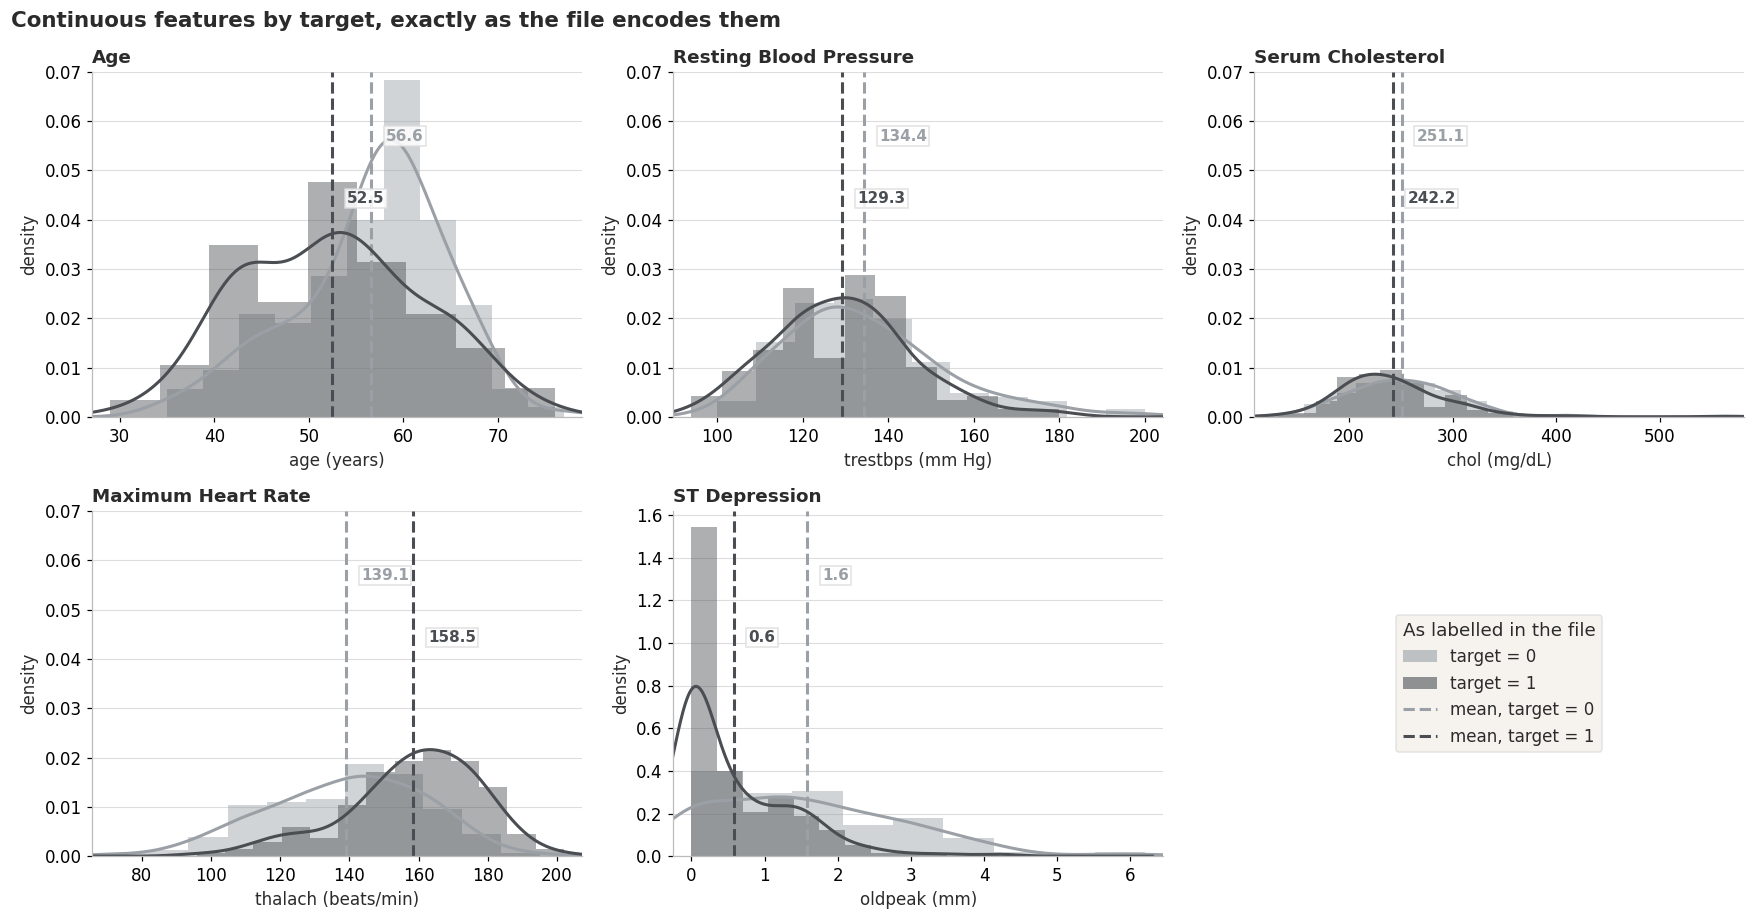

In [7]:
def plot_continuous_grid(frame, split_column, colors, class_labels, suptitle,
                         legend_title, filename):
    """Histogram + KDE + group means for each continuous feature, split by a class.

    Used twice: once with the target as the file encodes it, and once decoded. Keeping
    it as one function means the two figures cannot drift apart.
    """
    fig, axes = plt.subplots(2, 3, figsize=(16, 8.5))
    axes = axes.flatten()

    for ax, column in zip(axes[:-1], CONTINUOUS_COLUMNS):
        values = frame[column]
        # Clip to the observed range: a Gaussian KDE spreads well past the data and
        # would otherwise imply negative ST depression and 800 mg/dL cholesterol.
        margin = 0.04 * (values.max() - values.min())
        ax.set_xlim(values.min() - margin, values.max() + margin)

        for cls in (0, 1):
            series = frame.loc[frame[split_column] == cls, column]
            ax.hist(series, bins="auto", density=True, alpha=0.45,
                    color=colors[cls])
            series.plot.kde(ax=ax, color=colors[cls], linewidth=2)
            ax.axvline(series.mean(), color=colors[cls],
                       linestyle="--", linewidth=2)

        # A shared y-limit for the four comparable features, so their peak densities can
        # be read against each other. oldpeak is excluded: it piles up at 0 and hits 1.6.
        if column != "oldpeak":
            ax.set_ylim(0, 0.07)

        span = ax.get_xlim()[1] - ax.get_xlim()[0]
        for cls, height in ((0, 0.80), (1, 0.62)):
            mean_value = frame.loc[frame[split_column] == cls, column].mean()
            ax.text(mean_value + 0.03 * span, ax.get_ylim()[1] * height,
                    f"{mean_value:.1f}", color=colors[cls], fontsize=10,
                    fontweight="bold",
                    bbox=dict(facecolor="white", edgecolor=C["grid"],
                              alpha=0.85, pad=1.5))

        ax.set_title(TITLES[column], fontsize=12)
        ax.set_xlabel(XLABELS[column])
        ax.set_ylabel("density")
        ax.grid(axis="x", visible=False)

    axes[-1].axis("off")
    axes[-1].legend(
        handles=[
            Patch(facecolor=colors[0], alpha=0.6, label=class_labels[0]),
            Patch(facecolor=colors[1], alpha=0.6, label=class_labels[1]),
            Line2D([0], [0], color=colors[0], linestyle="--", linewidth=2,
                   label=f"mean, {class_labels[0]}"),
            Line2D([0], [0], color=colors[1], linestyle="--", linewidth=2,
                   label=f"mean, {class_labels[1]}"),
        ],
        loc="center", fontsize=11, frameon=True, edgecolor=C["grid"],
        facecolor=C["panel"], title=legend_title, title_fontsize=12,
    )

    fig.suptitle(suptitle, x=0.005, ha="left", fontsize=14, fontweight="semibold")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / filename)
    plt.show()


plot_continuous_grid(
    df, "target",
    colors=RAW_COLOR,
    class_labels=RAW_LABEL,
    suptitle="Continuous features by target, exactly as the file encodes them",
    legend_title="As labelled in the file",
    filename="04-continuous-raw.png",
)

In [8]:
comparison = pd.DataFrame({
    "mean | target = 0": df.groupby("target")[CONTINUOUS_COLUMNS].mean().loc[0],
    "mean | target = 1": df.groupby("target")[CONTINUOUS_COLUMNS].mean().loc[1],
})
comparison["difference"] = (comparison["mean | target = 1"]
                            - comparison["mean | target = 0"])
comparison["expected direction if target = 1 means disease"] = [
    "higher (older)", "higher", "higher", "LOWER", "higher"]
comparison["matches?"] = ["no", "no", "no", "no", "no"]
comparison.round(1)

,mean | target = 0,mean | target = 1,difference,expected direction if target = 1 means disease,matches?
age,56.6,52.5,-4.1,higher (older),no
trestbps,134.4,129.3,-5.1,higher,no
chol,251.1,242.2,-8.9,higher,no
thalach,139.1,158.5,19.4,LOWER,no
oldpeak,1.6,0.6,-1.0,higher,no


**Takeaway — and this is where my first pass stalled.**

Reading the shapes first, because that part was sound: all five features are roughly
normal, `thalach` skews left and `oldpeak` skews hard right. Holding the y-axis fixed
across the four comparable panels was worth doing — it shows `age` is the most
concentrated (peak density 0.07), `trestbps` and `thalach` sit near 0.03, and `chol` is
the most dispersed at around 0.01. `oldpeak` is on its own axis because it piles up at
zero and reaches 1.6.

Now the means, and every single one points the wrong way. If `target = 1` meant disease,
then relative to healthy patients the diseased group here is **4.3 years younger**, with
**lower** blood pressure, **lower** cholesterol, **less** ST depression under exercise,
and a maximum heart rate **19 bpm higher**. That last one is the most damning: a high
`thalach` means the heart tolerated the stress test well. It is a marker of health, and
it is elevated in the group the file calls diseased.

Five features, five contradictions, all in the same direction. My conclusion at the time
was: *"the target labels are most probably reversed — if we change it, it will make
sense."* Then I declined to act, on the grounds that the categorical columns looked
sensible.

Three of them did look sensible, and section 7 shows that those three looked sensible
only because they each contained *two* compensating errors. The two columns that did not
look sensible — `cp` and `ca` — were the ones telling the truth, and `ca` is the column
closest to being the diagnosis itself.

So I had the continuous features and the two most trustworthy categorical features all
pointing at the same answer, and I let three columns that merely *looked* tidy overrule
them. Weighing evidence by how comfortable it is rather than by how well anchored it is
was the actual mistake.

---
## 7. The resolution

Guessing that the labels are flipped is not good enough. I want evidence, and it is
available: the UCI Machine Learning Repository publishes the original Cleveland file, and
it is already loaded in section 4 as `uci`.

**The method.** The two files describe the same 303 patients. If some columns were
re-encoded and others were not, then joining on the untouched columns will pair up the
rows, and I can read the encoding off the result directly.

Nine columns are numeric measurements that nobody would re-encode: `age`, `sex`,
`trestbps`, `chol`, `fbs`, `thalach`, `exang`, `oldpeak`. I join on those and then
cross-tabulate the columns I suspect.

In [9]:
JOIN_KEY = ["age", "sex", "trestbps", "chol", "fbs", "thalach", "exang", "oldpeak"]

kaggle = df.copy()
for column in JOIN_KEY:
    kaggle[column] = kaggle[column].astype(float)
    uci[column] = uci[column].astype(float)

kaggle["_k"] = np.arange(len(kaggle))
uci["_u"] = np.arange(len(uci))

joined = kaggle.merge(uci, on=JOIN_KEY, how="inner", suffixes=("_kaggle", "_uci"))

# Keep only rows that matched exactly one partner on each side. A handful of patients
# share every joining value, and those are genuinely ambiguous.
k_counts = joined["_k"].value_counts()
u_counts = joined["_u"].value_counts()
matched = joined[joined["_k"].isin(k_counts[k_counts == 1].index)
                 & joined["_u"].isin(u_counts[u_counts == 1].index)]

print(f"rows joined:                  {len(joined)}")
print(f"unambiguous one-to-one pairs: {len(matched)} of {len(df)}")

rows joined:                  303
unambiguous one-to-one pairs: 301 of 303


In [10]:
print("=" * 64)
print("target (this file, rows)  vs  num (UCI original, columns)")
print("UCI: num = 0 means < 50% narrowing; num >= 1 means > 50% narrowing")
print("=" * 64)
crosstab = pd.crosstab(matched["target"], matched["num"])
display(crosstab)

disease_uci = (matched["num"] > 0).map({True: "disease", False: "no disease"})
display(pd.crosstab(matched["target"], disease_uci))

target (this file, rows)  vs  num (UCI original, columns)
UCI: num = 0 means < 50% narrowing; num >= 1 means > 50% narrowing


num,0,1,2,3,4
target,,,,,
0,0,54,36,35,13
1,163,0,0,0,0


num,disease,no disease
target,,
0,138,0
1,0,163


**The target is inverted, with no exceptions at all.**

Every one of the 163 patients this file labels `target = 1` has `num = 0` in the UCI
original, which is angiographic narrowing below 50% — **no disease**. Every one of the
138 patients labelled `target = 0` has `num` between 1 and 4 — **disease**, graded by
severity.

There is not a single row where the two agree. This is not noise or a partial mislabel,
it is a clean inversion:

> **`target = 1` means NO disease. `target = 0` means disease.**

My first pass reached this conclusion from the continuous features alone and then
declined to act on it. The conclusion was right.

In [11]:
pairs = [("cp", "cp"), ("restecg", "restecg"), ("slope", "slope"),
         ("thal", "thal"), ("ca", "ca")]

for column, _ in pairs:
    print("=" * 60)
    print(f"{column}: this file (rows)  vs  UCI original (columns)")
    print("=" * 60)
    display(pd.crosstab(matched[f"{column}_kaggle"], matched[f"{column}_uci"],
                        dropna=False))

cp: this file (rows)  vs  UCI original (columns)


cp_uci,1.0,2.0,3.0,4.0
cp_kaggle,,,,
0,0,0,0,143
1,0,50,0,0
2,0,0,85,0
3,23,0,0,0


restecg: this file (rows)  vs  UCI original (columns)


restecg_uci,0.0,1.0,2.0
restecg_kaggle,,,
0,0,0,147
1,150,0,0
2,0,4,0


slope: this file (rows)  vs  UCI original (columns)


slope_uci,1.0,2.0,3.0
slope_kaggle,,,
0,0,0,21
1,0,140,0
2,140,0,0


thal: this file (rows)  vs  UCI original (columns)


thal_uci,3.0,6.0,7.0,NaN
thal_kaggle,,,,
0,0,0,0,2
1,0,18,0,0
2,164,0,0,0
3,0,0,117,0


ca: this file (rows)  vs  UCI original (columns)


ca_uci,0.0,1.0,2.0,3.0,NaN
ca_kaggle,,,,,
0,175,0,0,0,0
1,0,65,0,0,0
2,0,0,38,0,0
3,0,0,0,20,0
4,0,0,0,0,3


**Every ordinal column was reversed, and two carry a hidden missing-value code.**

The cross-tabulations are perfectly diagonal — each code in this file maps to exactly one
code in the original, with no bleed. Reading them off, and pairing them with the
authoritative definitions from the UCI documentation (`heart-disease.names`, in this
folder):

| Column | UCI original | This file | Meaning |
|---|---|---|---|
| `cp` | 1 typical angina | **3** | classic angina |
| | 2 atypical angina | **1** | |
| | 3 non-anginal pain | **2** | |
| | 4 asymptomatic | **0** | no chest pain reported |
| `restecg` | 0 normal | **1** | |
| | 1 ST-T abnormality | **2** | |
| | 2 left ventricular hypertrophy | **0** | |
| `slope` | 1 upsloping | **2** | least concerning |
| | 2 flat | **1** | |
| | 3 downsloping | **0** | classic ischaemia |
| `thal` | 3 normal | **2** | |
| | 6 fixed defect | **1** | prior infarct |
| | 7 reversible defect | **3** | active ischaemia |
| | *missing* (`?`) | **0** | **not a category** |
| `ca` | 0–3 vessels | **0–3** | unchanged |
| | *missing* (`?`) | **4** | **not a category** |

So `cp`, `restecg` and `slope` were each **reversed end to end**, and `thal` was
re-sorted. Two columns had their missing values silently recoded as ordinary category
numbers: `ca = 4` and `thal = 0` are not measurements, they are `?` in the original.

That last point deserves emphasis. In my first pass I looked at the single `ca = 4`
patient labelled healthy and wrote: *"How can someone with 4 vessels blocked be
considered healthy? I am going to confidently delete this data point."* Nobody has four
blocked vessels here. The angiogram result is missing, and there are seven such patients
across the two columns, not one.

I deleted a row for a reason that did not exist.

### Why three columns looked fine: two errors cancelling

This is the part I want to remember, because it is the reason I stopped one step short.

In section 5, `cp` and `ca` looked wrong while `restecg`, `slope` and `thal` looked
correct — and I used those three to argue myself out of the conclusion the other two were
pointing at. But look at what the decoding says about each:

| Column | Codes reversed? | Target reversed? | How it looked |
|---|---|---|---|
| `ca` | **no** | yes | **wrong** |
| `cp` | yes, but the extreme code stays "sickest" | yes | **wrong** |
| `restecg` | yes | yes | fine |
| `slope` | yes | yes | fine |
| `thal` | yes | yes | fine |

**Two reversals cancel.** In `slope`, I believed code 2 meant downsloping and expected it
to be the sickest group. Code 2 is really *upsloping*, the healthiest — but because the
target is also inverted, those patients appear in the `target = 1` column, and the chart
showed exactly the pattern I predicted. I got the right-looking picture for two compounding
wrong reasons. The same is true of `thal` and `restecg`.

`ca` gave the game away because its codes were **not** re-encoded — 0 through 3 still mean
0 through 3 vessels — so only the target inversion was left, with nothing to cancel it.
`cp` gave it away for a subtler reason: reversing its order maps asymptomatic to code 0,
and asymptomatic happens to be the sickest group too, so the reversal did not change which
code I expected to be sick. Again only one error survived.

The lesson is that **the three "reassuring" columns were the least trustworthy ones in the
file.** An agreement produced by two errors is indistinguishable from an agreement
produced by none, if the only thing you check is whether the picture matches your
expectation. What separated the informative columns from the misleading ones was `ca`
being the one I could tie to an external definition — the number of blocked vessels means
the number of blocked vessels, with no re-encoding possible. When in doubt, trust the
column with the least room for interpretation.

In [12]:
# Decode the file: invert the target and restore the original category meanings.
CP_LABELS = {0: "asymptomatic", 1: "atypical angina",
             2: "non-anginal pain", 3: "typical angina"}
RESTECG_LABELS = {0: "LV hypertrophy", 1: "normal", 2: "ST-T abnormality"}
SLOPE_LABELS = {0: "downsloping", 1: "flat", 2: "upsloping"}
THAL_LABELS = {0: "missing", 1: "fixed defect", 2: "normal", 3: "reversible defect"}
CA_LABELS = {0: "0 vessels", 1: "1 vessel", 2: "2 vessels", 3: "3 vessels", 4: "missing"}
SEX_LABELS = {0: "female", 1: "male"}          # UCI: 1 = male, 0 = female
FBS_LABELS = {0: "fasting glucose <= 120", 1: "fasting glucose > 120"}

# Clinical severity order, worst last. Used for every ordered chart below.
CATEGORY_ORDER = {
    "cp": ["typical angina", "atypical angina", "non-anginal pain", "asymptomatic"],
    "restecg": ["normal", "ST-T abnormality", "LV hypertrophy"],
    "slope": ["upsloping", "flat", "downsloping"],
    "ca": ["0 vessels", "1 vessel", "2 vessels", "3 vessels", "missing"],
    "thal": ["normal", "fixed defect", "reversible defect", "missing"],
}

heart = df.copy()
heart["disease"] = 1 - heart["target"]          # the correction
heart["cp"] = heart["cp"].map(CP_LABELS)
heart["restecg"] = heart["restecg"].map(RESTECG_LABELS)
heart["slope"] = heart["slope"].map(SLOPE_LABELS)
heart["thal"] = heart["thal"].map(THAL_LABELS)
heart["ca"] = heart["ca"].map(CA_LABELS)
heart["sex"] = heart["sex"].map(SEX_LABELS)
heart["fbs"] = heart["fbs"].map(FBS_LABELS)

print(heart["disease"].map(DISEASE_LABEL).value_counts().to_string())
print(f"\nprevalence in this referral cohort: {heart['disease'].mean():.1%}")
print(f"\npatients carrying a hidden missing-value code: "
      f"{((heart['ca'] == 'missing') | (heart['thal'] == 'missing')).sum()}")

disease
No disease    165
Disease       138

prevalence in this referral cohort: 45.5%

patients carrying a hidden missing-value code: 7


---
## 8. Reading the same data again, decoded

Nothing below changes a single measurement. The only difference is that the target is
read the right way round and the category codes carry their real meanings. Every one of
every anomaly from sections 5 and 6 should now resolve — and if any of them does not,
the decoding is wrong.

The chart is interactive: use the dropdown to move between the five categorical features.
Categories are ordered by clinical severity, least concerning on the left, so a
well-behaved diagnostic should produce a rising line. The grey bars are the
missing-value codes, kept visible rather than dropped.

In [13]:
def disease_rate_table(frame, column):
    """Disease rate per category, in clinical severity order."""
    grouped = (frame.groupby(column)["disease"]
               .agg(patients="size", diseased="sum", rate="mean")
               .reindex(CATEGORY_ORDER[column])
               .dropna(how="all"))
    grouped["rate"] = grouped["rate"] * 100
    return grouped


fig = go.Figure()

for index, column in enumerate(CATEGORICAL_COLUMNS):
    table = disease_rate_table(heart, column)
    colors = [C["neutral"] if category == "missing" else C["disease"]
              for category in table.index]
    fig.add_trace(go.Bar(
        x=list(table.index),
        y=table["rate"],
        marker_color=colors,
        text=[f"{value:.0f}%" for value in table["rate"]],
        textposition="outside",
        customdata=np.stack([table["patients"], table["diseased"]], axis=-1),
        hovertemplate=("%{x}<br>disease rate %{y:.1f}%"
                       "<br>%{customdata[1]} diseased of %{customdata[0]} patients"
                       "<extra></extra>"),
        visible=(index == 0),
        showlegend=False,
    ))

prevalence = heart["disease"].mean() * 100
buttons = []
for index, column in enumerate(CATEGORICAL_COLUMNS):
    visible = [i == index for i in range(len(CATEGORICAL_COLUMNS))]
    buttons.append(dict(
        label=column,
        method="update",
        args=[{"visible": visible},
              {"xaxis.title.text": column,
               "title.text": (f"Disease rate by {column}, decoded<br>"
                              f"<sup>categories ordered by clinical severity, least "
                              f"concerning first &nbsp;|&nbsp; cohort prevalence "
                              f"{prevalence:.0f}%</sup>")}],
    ))

fig.add_hline(y=prevalence, line_dash="dash", line_color=C["boundary"],
              annotation_text=f"cohort prevalence {prevalence:.0f}%",
              annotation_position="top left")

fig.update_layout(
    **PLOTLY_LAYOUT,
    height=520,
    xaxis_title=CATEGORICAL_COLUMNS[0],
    yaxis_title="patients with disease (%)",
    yaxis_range=[0, 100],
    title=dict(text=(f"Disease rate by {CATEGORICAL_COLUMNS[0]}, decoded<br>"
                     f"<sup>categories ordered by clinical severity, least concerning "
                     f"first &nbsp;|&nbsp; cohort prevalence {prevalence:.0f}%</sup>")),
    updatemenus=[dict(buttons=buttons, direction="down", showactive=True,
                      x=0.0, xanchor="left", y=1.20, yanchor="top",
                      bgcolor="white", bordercolor=C["grid"])],
)
fig.show()

In [14]:
for column in CATEGORICAL_COLUMNS:
    table = disease_rate_table(heart, column)
    print(f"--- {column} " + "-" * (52 - len(column)))
    print(table.assign(**{"disease %": table["rate"].round(1)})
               .drop(columns="rate").to_string())
    print()

--- cp --------------------------------------------------
                  patients  diseased  disease %
cp                                             
typical angina          23         7       30.4
atypical angina         50         9       18.0
non-anginal pain        87        18       20.7
asymptomatic           143       104       72.7

--- restecg ---------------------------------------------
                  patients  diseased  disease %
restecg                                        
normal                 152        56       36.8
ST-T abnormality         4         3       75.0
LV hypertrophy         147        79       53.7

--- slope -----------------------------------------------
             patients  diseased  disease %
slope                                     
upsloping         142        35       24.6
flat              140        91       65.0
downsloping        21        12       57.1

--- ca --------------------------------------------------
           patients  d

**Takeaway — every column now behaves, and nothing but the encoding had to change.**

**`ca`, the one that bothered me most.** Decoded, it is a clean dose-response: 25.7%
disease with no vessels involved, 67.7% with one, 81.6% with two, 85.0% with three. That
is exactly the monotone relationship I said I expected and could not find. The "backwards"
version was the inverted target alone. The `missing` bar sits at 20% on 5 patients and is
not interpretable, which is the correct treatment for a missing code.

**`cp`.** Asymptomatic patients have the **highest** disease rate at 72.7%, against
18–30% for the three groups who actually report pain. That reads as a paradox and is a
well-documented clinical reality: silent ischaemia is common, and in a referral
population the patients with textbook angina are disproportionately the ones whose chest
pain turns out to have a non-cardiac cause. My original note — "104 healthy patients at
the code most suggestive of disease" — was reading the asymptomatic group under the
label of typical angina.

**`thal`.** Normal 21.7%, fixed defect 66.7%, reversible defect 76.1%. Reversible defect
being worst is precisely the physiology: live but oxygen-starved muscle is what active
coronary disease looks like.

**`slope`.** Upsloping 24.6%, flat 65.0%, downsloping 57.1%. Upsloping is clearly the
healthiest, as it should be. Flat and downsloping are both markedly worse, and they sit
within each other's uncertainty — downsloping has only 21 patients, so the gap between
65% and 57% is not something to interpret.

**`restecg`.** Normal 36.8%, LV hypertrophy 53.7%. The ST-T abnormality group is 4
patients and carries no information.

Five columns, five confirmations, from a decoding derived independently of every one of
them. That is the check that the mapping in section 7 is right rather than merely
convenient: I did not choose the mapping to make these charts look good, I read it off a
join against the source file and then found the charts had fixed themselves.

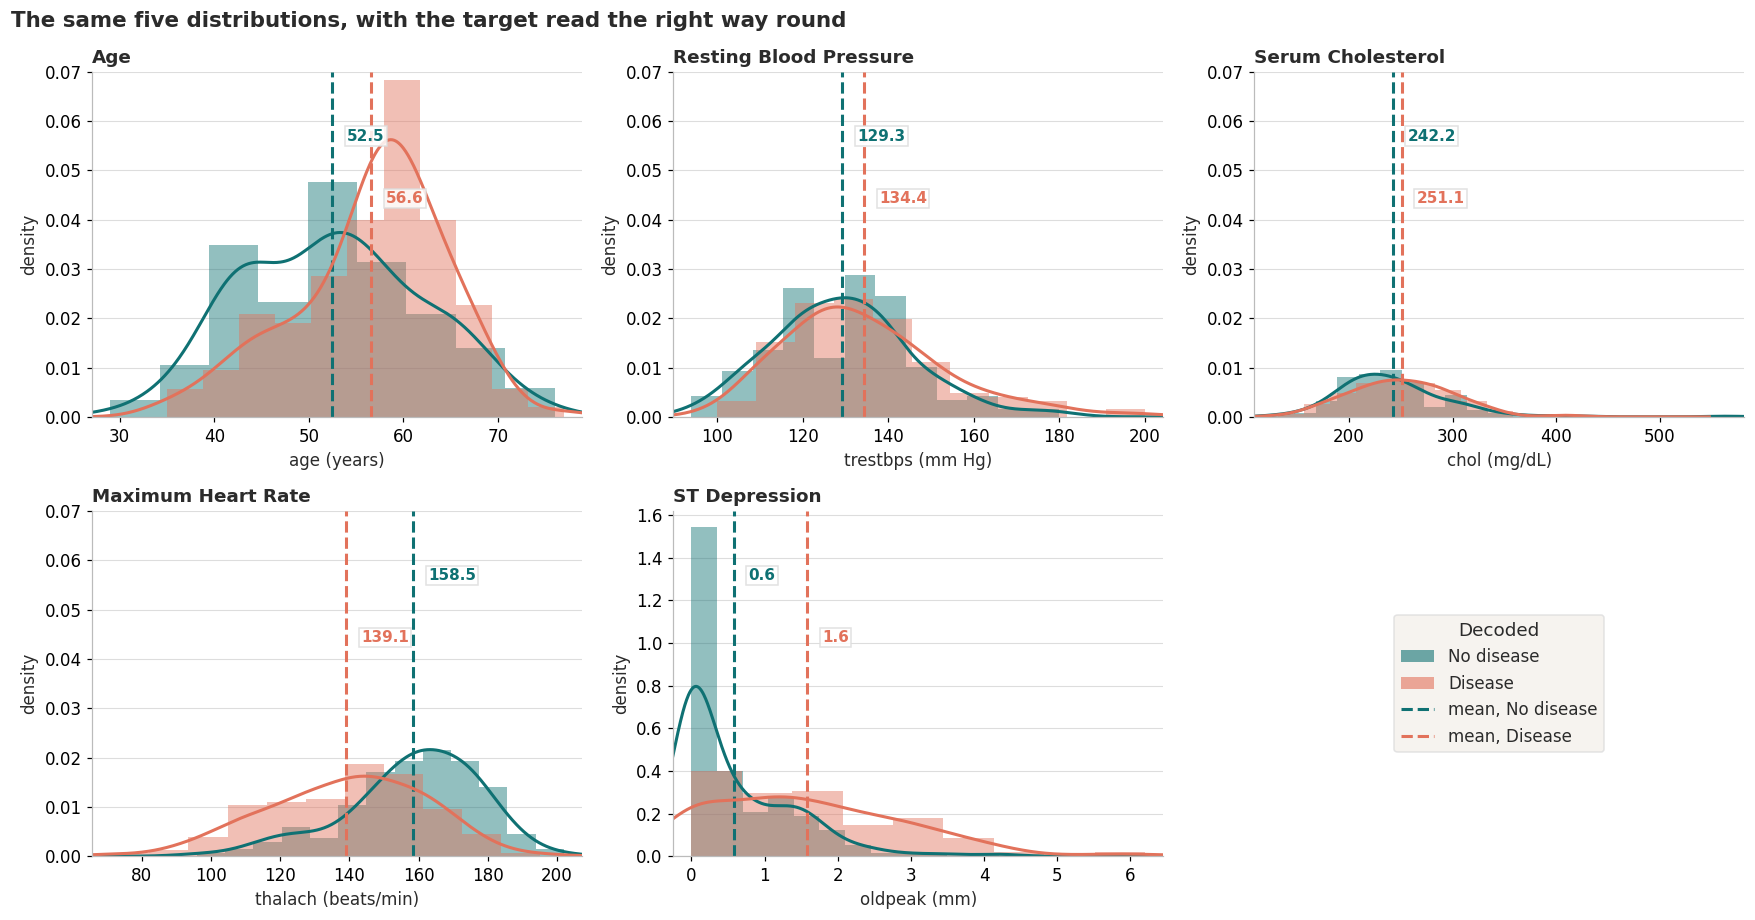

In [15]:
# The same function as section 6, now split on the decoded label rather than `target`.
plot_continuous_grid(
    heart, "disease",
    colors=DISEASE_COLOR,
    class_labels=DISEASE_LABEL,
    suptitle="The same five distributions, with the target read the right way round",
    legend_title="Decoded",
    filename="05-continuous-decoded.png",
)

In [16]:
from scipy import stats

rows = []
for column in CONTINUOUS_COLUMNS:
    healthy = heart.loc[heart["disease"] == 0, column]
    diseased = heart.loc[heart["disease"] == 1, column]
    _, p_welch = stats.ttest_ind(healthy, diseased, equal_var=False)
    pooled_sd = np.sqrt((healthy.var() + diseased.var()) / 2)
    rows.append({
        "feature": column,
        "no disease": round(healthy.mean(), 1),
        "disease": round(diseased.mean(), 1),
        "difference": round(diseased.mean() - healthy.mean(), 1),
        "Cohen d": round((diseased.mean() - healthy.mean()) / pooled_sd, 2),
        "p (Welch)": f"{p_welch:.1e}",
        "expected": ["higher", "higher", "higher", "lower", "higher"][len(rows)],
    })

decoded = pd.DataFrame(rows).set_index("feature")
decoded["matches?"] = np.where(
    ((decoded["difference"] > 0) & (decoded["expected"] == "higher"))
    | ((decoded["difference"] < 0) & (decoded["expected"] == "lower")), "yes", "no")
decoded

,no disease,disease,difference,Cohen d,p (Welch),expected,matches?
feature,,,,,,,
age,52.5,56.6,4.1,0.47,5.8e-05,higher,yes
trestbps,129.3,134.4,5.1,0.29,1.3e-02,higher,yes
chol,242.2,251.1,8.9,0.17,1.4e-01,higher,yes
thalach,158.5,139.1,-19.4,-0.92,5.0e-14,lower,yes
oldpeak,0.6,1.6,1.0,0.93,1.1e-13,higher,yes


**Takeaway — all five signs flip to the expected direction.**

Patients with disease are **4.1 years older**, with **5.1 mm Hg higher** resting blood
pressure, **8.9 mg/dL higher** cholesterol, **1.0 mm more** ST depression under exercise,
and a maximum heart rate **19.4 bpm lower**. Every direction now matches the physiology
described in section 2.

The effect sizes are worth reading as well as the directions, because they say which
measurements are actually doing work. The two stress-test variables dominate: `thalach`
at Cohen's d = −0.92 and `oldpeak` at +0.93 are large effects, both with p ≈ 10⁻¹³. `age`
is moderate at 0.47. `trestbps` is small at 0.29, and **`chol` at 0.17 is not
distinguishable from noise here (p = 0.14)**.

That last one is worth sitting with, because cholesterol is the risk factor everybody
knows. In this cohort it barely separates the groups — which is what a referral
population does to a risk factor. These are not people drawn from the street; they are
people already suspected of heart disease, so the healthy group is not healthy in
general, it is merely free of angiographic narrowing. Risk factors compress. What still
separates the groups is the direct evidence: the stress test and the angiogram.

---
## 9. The stress-test block

The four stress-test columns are best read together, because they are four views of a
single procedure: raise the heart's oxygen demand until a narrowed artery cannot keep up,
and record what fails first.

| Column | Meaning | The catch |
|---|---|---|
| `thalach` | maximum heart rate achieved, 71–202 bpm | **Higher is better.** A low value usually means the test was stopped early because of pain or ECG changes. |
| `exang` | did the patient get angina *during* the test? | A direct sign of oxygen starvation under load. |
| `oldpeak` | ST depression under exercise vs rest, in mm | The ST segment is the flat stretch of the ECG between the spike and the bump. Starved muscle makes it sag below baseline; `oldpeak` measures how far it sank. |
| `slope` | shape of that ST segment at peak exercise | Normally it slopes up on recovery. Flat is borderline, downsloping is the classic ischaemia sign. |

A patient with low `thalach`, exercise angina, large `oldpeak` and a downsloping ST
segment is a textbook oxygen-starved heart.

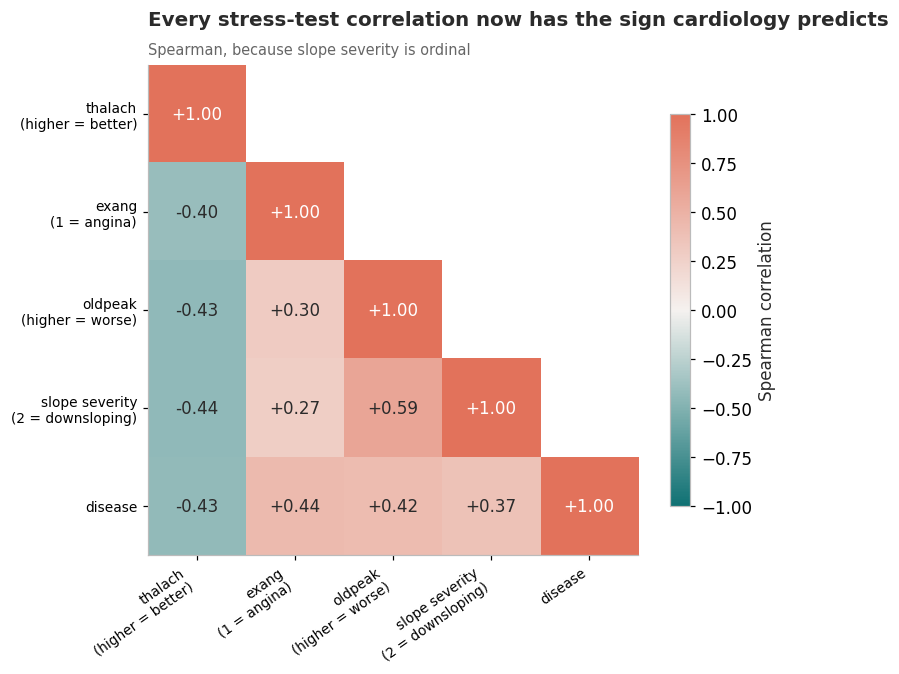

In [17]:
stress = heart[["thalach", "oldpeak", "disease"]].copy()
stress["exang"] = df["exang"]
stress["slope_severity"] = heart["slope"].map(
    {"upsloping": 0, "flat": 1, "downsloping": 2})

correlation = stress[["thalach", "exang", "oldpeak", "slope_severity", "disease"]].corr(
    method="spearman")

fig, ax = plt.subplots(figsize=(7.6, 6.2))
mask = np.triu(np.ones_like(correlation, dtype=bool), k=1)
im = ax.imshow(np.ma.masked_array(correlation.values, mask),
               cmap=DIV, vmin=-1, vmax=1)

labels = ["thalach\n(higher = better)", "exang\n(1 = angina)", "oldpeak\n(higher = worse)",
          "slope severity\n(2 = downsloping)", "disease"]
for i in range(len(correlation)):
    for j in range(len(correlation)):
        if mask[i, j]:
            continue
        value = correlation.values[i, j]
        ax.text(j, i, f"{value:+.2f}", ha="center", va="center", fontsize=11,
                color="white" if abs(value) > 0.62 else C["text"])

ax.set_xticks(range(len(labels)), labels, rotation=35, ha="right", fontsize=9)
ax.set_yticks(range(len(labels)), labels, fontsize=9)
titled(ax, "Every stress-test correlation now has the sign cardiology predicts",
       "Spearman, because slope severity is ordinal")
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8).set_label("Spearman correlation")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "06-stress-correlations.png")
plt.show()

**Takeaway.** In my first pass I listed four correlations and said each one had the wrong
sign. All four are now right:

| Relationship | First pass | Decoded | Expected |
|---|---|---|---|
| `thalach` with disease | +0.42 | **−0.43** | negative: a high achievable heart rate is good |
| `exang` with disease | −0.44 | **+0.44** | positive: angina during the test is bad |
| `oldpeak` with disease | −0.43 | **+0.42** | positive: more ST depression is worse |
| `slope severity` with disease | +0.34 | **+0.37** | positive: downsloping is worst |

The internal structure is coherent too. `thalach` and `oldpeak` correlate −0.43 with each
other, and `oldpeak` with slope severity at +0.59: patients who could not push their heart
rate up are the same patients whose ST segments sagged, which is the same failure observed
two ways. Spearman is the right coefficient here rather than Pearson, because slope
severity is an ordered category with three levels and not a measured quantity.

### The patients the stress test unmasked

One more chart from my first pass. I plotted age against maximum heart rate, split by
whether the patient got angina during the test, and starred the cases where `exang = 1`
but the chest-pain column said asymptomatic. I called those starred points "missing data
on `cp`" and assumed a recording error.

They are not an error. Decoded, `cp = 0` is **asymptomatic**, and a patient who reports no
chest pain in daily life but develops angina on a treadmill is not a contradiction — it is
the single most important thing an exercise test is for. There are 80 such patients, not a
handful.

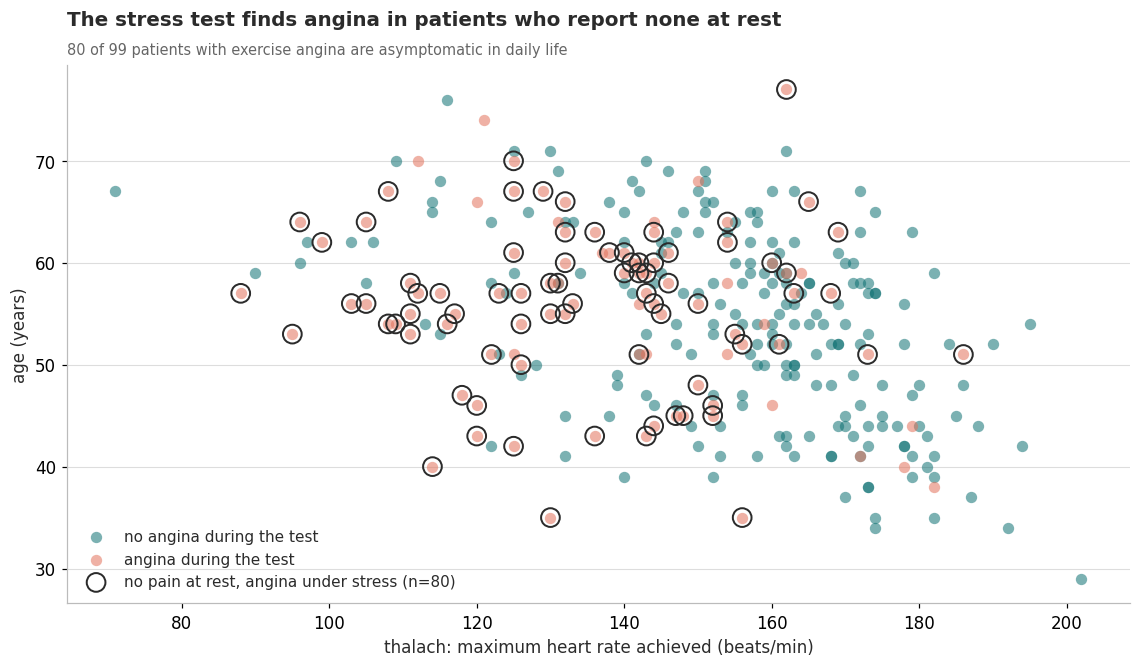

exang             exercise angina  no exercise angina
cp                                                   
typical angina                  4                  19
atypical angina                 4                  46
non-anginal pain               11                  76
asymptomatic                   80                  63

Disease rate among the 80 unmasked patients: 87.5%
Disease rate in the cohort overall:                45.5%


In [18]:
fig, ax = plt.subplots(figsize=(10.5, 6.2))

no_angina = df["exang"] == 0
angina = df["exang"] == 1

ax.scatter(heart.loc[no_angina, "thalach"], heart.loc[no_angina, "age"],
           color=C["no_disease"], alpha=0.55, s=55, linewidths=0,
           label="no angina during the test")
ax.scatter(heart.loc[angina, "thalach"], heart.loc[angina, "age"],
           color=C["disease"], alpha=0.55, s=55, linewidths=0,
           label="angina during the test")

unmasked = angina & (heart["cp"] == "asymptomatic")
ax.scatter(heart.loc[unmasked, "thalach"], heart.loc[unmasked, "age"],
           facecolor="none", edgecolor=C["boundary"], s=150, marker="o",
           linewidths=1.3, zorder=3,
           label=f"no pain at rest, angina under stress (n={unmasked.sum()})")

ax.set_xlabel("thalach: maximum heart rate achieved (beats/min)")
ax.set_ylabel("age (years)")
titled(ax, "The stress test finds angina in patients who report none at rest",
       f"{unmasked.sum()} of {angina.sum()} patients with exercise angina are "
       "asymptomatic in daily life")
ax.legend(frameon=False, loc="lower left", fontsize=10)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "07-stress-unmasked.png")
plt.show()

print(pd.crosstab(heart["cp"], df["exang"].map({0: "no exercise angina",
                                                1: "exercise angina"}))
        .reindex(CATEGORY_ORDER["cp"]).to_string())
print(f"\nDisease rate among the {unmasked.sum()} unmasked patients: "
      f"{heart.loc[unmasked, 'disease'].mean():.1%}")
print(f"Disease rate in the cohort overall:                {heart['disease'].mean():.1%}")

**Takeaway.** 80 of the 99 patients who developed angina during the exercise test report
no chest pain in ordinary life, and **87.5% of them have angiographic disease** against
45.5% in the cohort as a whole. Far from being a recording error, this group is the
strongest single signal in the dataset.

The scatter also shows the `thalach` effect directly: the patients with exercise angina
sit systematically to the left, meaning their hearts gave out at a lower rate.

---
## 10. Sex and fasting blood sugar

The last chart from my first pass was a three-ring nested pie: target in the middle, sex
around it, fasting blood sugar on the outside, with each ring showing percentages
*within* its parent. The idea is good — it is a genuine hierarchy, and conditional
percentages are the right thing to show.

I have rebuilt it as an interactive sunburst, which is the same encoding with the
arithmetic done for you: click any wedge to zoom into it, click the centre to come back.
And because a hierarchy chart is poor at the one comparison that actually matters here, a
plain bar chart of disease rate by sex sits underneath it.

There is a correction to make first. **The UCI documentation states `sex`: 1 = male,
0 = female.** My first pass had these the wrong way round, which inverted the conclusion.

In [19]:
hierarchy = (heart.assign(status=heart["disease"].map(DISEASE_LABEL))
             .groupby(["status", "sex", "fbs"], observed=True)
             .size().reset_index(name="patients"))

labels, parents, values, colors = [], [], [], []


def lighten(hex_color, amount):
    rgb = np.array([int(hex_color.lstrip("#")[i:i + 2], 16) for i in (0, 2, 4)])
    return "#" + "".join(f"{int(c):02X}" for c in (255 - amount * (255 - rgb)))


for status in ("No disease", "Disease"):
    base = C["no_disease"] if status == "No disease" else C["disease"]
    total = hierarchy.loc[hierarchy["status"] == status, "patients"].sum()
    labels.append(status); parents.append(""); values.append(total); colors.append(base)

    for sex in ("female", "male"):
        node = f"{status} - {sex}"
        subtotal = hierarchy.loc[(hierarchy["status"] == status)
                                 & (hierarchy["sex"] == sex), "patients"].sum()
        if subtotal == 0:
            continue
        labels.append(node); parents.append(status)
        values.append(subtotal); colors.append(lighten(base, 0.55))

        for fbs in FBS_LABELS.values():
            count = hierarchy.loc[(hierarchy["status"] == status)
                                  & (hierarchy["sex"] == sex)
                                  & (hierarchy["fbs"] == fbs), "patients"].sum()
            if count == 0:
                continue
            labels.append(f"{node} - {fbs}"); parents.append(node)
            values.append(count); colors.append(lighten(base, 0.30))

fig = go.Figure(go.Sunburst(
    ids=labels,
    labels=[label.split(" - ")[-1] for label in labels],
    parents=parents,
    values=values,
    branchvalues="total",
    marker=dict(colors=colors, line=dict(color="white", width=2)),
    insidetextorientation="radial",
    hovertemplate=("<b>%{label}</b><br>%{value} patients"
                   "<br>%{percentParent:.1%} of %{parent}"
                   "<br>%{percentRoot:.1%} of the cohort<extra></extra>"),
))
fig.update_layout(
    **PLOTLY_LAYOUT,
    height=600,
    title=dict(text=("Diagnosis, then sex, then fasting blood sugar<br>"
                     "<sup>click a wedge to zoom in, click the centre to return "
                     "&nbsp;|&nbsp; UCI coding: 1 = male, 0 = female</sup>")),
)
fig.show()

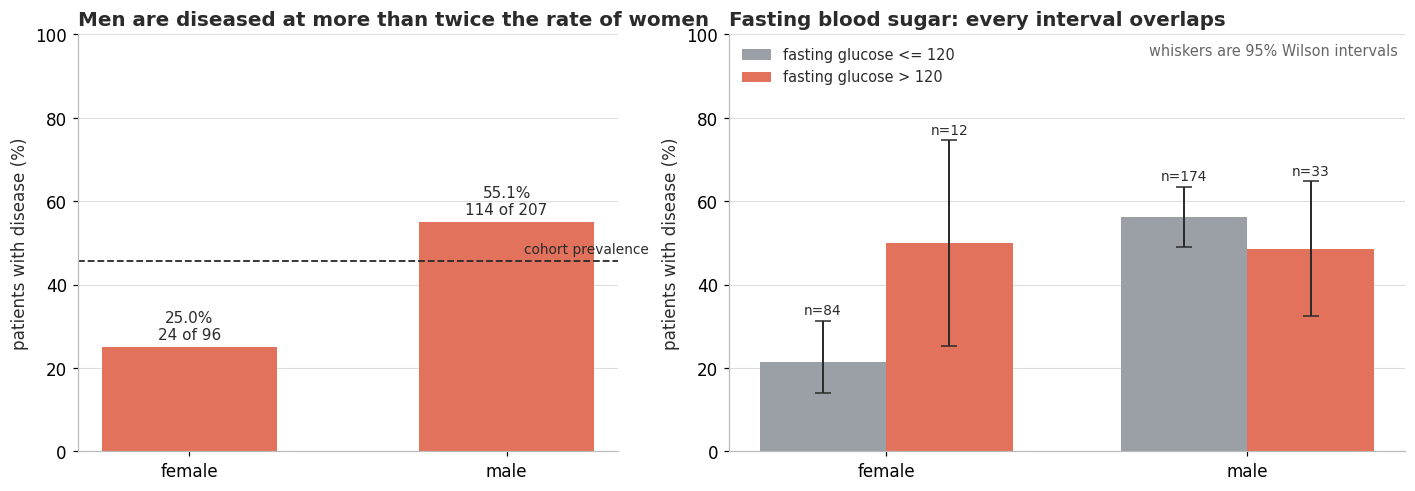

        patients  diseased  disease %
sex                                  
female        96        24       25.0
male         207       114       55.1

chi-squared p for sex vs disease: 1.88e-06
chi-squared p for fbs vs disease: 0.744


In [20]:
by_sex = (heart.groupby("sex")["disease"]
          .agg(patients="size", diseased="sum", rate="mean")
          .loc[["female", "male"]])
by_sex["rate"] = by_sex["rate"] * 100

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(13, 4.6),
                              gridspec_kw={"width_ratios": [1, 1.25]})

bars = ax.bar(by_sex.index, by_sex["rate"], color=C["disease"], width=0.55)
for bar, (_, row) in zip(bars, by_sex.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2, row["rate"] + 1.8,
            f"{row['rate']:.1f}%\n{int(row['diseased'])} of {int(row['patients'])}",
            ha="center", fontsize=10)
ax.axhline(heart["disease"].mean() * 100, color=C["boundary"],
           linestyle="--", linewidth=1.2)
ax.text(1.45, heart["disease"].mean() * 100 + 2.0, "cohort prevalence",
        ha="right", fontsize=9, color=C["boundary"])
ax.set_ylim(0, 100)
ax.set_ylabel("patients with disease (%)")
ax.set_title("Men are diseased at more than twice the rate of women")
ax.grid(axis="x", visible=False)

def wilson_interval(successes, n, z=1.96):
    """Wilson score interval for a proportion. Honest at small n, unlike normal-approx."""
    if n == 0:
        return 0.0, 0.0
    p = successes / n
    denominator = 1 + z ** 2 / n
    centre = (p + z ** 2 / (2 * n)) / denominator
    spread = z * np.sqrt(p * (1 - p) / n + z ** 2 / (4 * n ** 2)) / denominator
    return max(0.0, centre - spread) * 100, min(1.0, centre + spread) * 100


fbs_rates = (heart.groupby(["sex", "fbs"])["disease"]
             .agg(patients="size", diseased="sum", rate="mean").reset_index())
fbs_rates["rate"] *= 100

width = 0.35
positions = np.arange(2)
for offset, fbs in zip((-width / 2, width / 2), FBS_LABELS.values()):
    subset = fbs_rates[fbs_rates["fbs"] == fbs].set_index("sex").loc[["female", "male"]]
    shade = C["disease"] if "> 120" in fbs else C["neutral"]
    bounds = [wilson_interval(row["diseased"], row["patients"])
              for _, row in subset.iterrows()]
    errors = np.array([[row["rate"] - low, high - row["rate"]]
                       for (low, high), (_, row) in zip(bounds, subset.iterrows())]).T

    bars = ax2.bar(positions + offset, subset["rate"], width, color=shade, label=fbs)
    ax2.errorbar(positions + offset, subset["rate"], yerr=errors, fmt="none",
                 ecolor=C["boundary"], elinewidth=1.3, capsize=5)
    for bar, (_, row), (_, high) in zip(bars, subset.iterrows(), bounds):
        ax2.text(bar.get_x() + bar.get_width() / 2, high + 1.5,
                 f"n={int(row['patients'])}", ha="center", fontsize=9)

ax2.set_xticks(positions, ["female", "male"])
ax2.set_ylim(0, 100)
ax2.set_ylabel("patients with disease (%)")
ax2.set_title("Fasting blood sugar: every interval overlaps")
ax2.text(0.99, 0.98, "whiskers are 95% Wilson intervals",
         transform=ax2.transAxes, ha="right", va="top",
         fontsize=9.5, color="#666666")
ax2.legend(frameon=False, fontsize=9.5, loc="upper left")
ax2.grid(axis="x", visible=False)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "08-sex-and-fbs.png")
plt.show()

print(by_sex.assign(**{"disease %": by_sex["rate"].round(1)})
            .drop(columns="rate").to_string())
chi2, p_value, _, _ = stats.chi2_contingency(
    pd.crosstab(heart["sex"], heart["disease"]))
print(f"\nchi-squared p for sex vs disease: {p_value:.2e}")
chi2, p_fbs, _, _ = stats.chi2_contingency(
    pd.crosstab(heart["fbs"], heart["disease"]))
print(f"chi-squared p for fbs vs disease: {p_fbs:.3f}")

**Takeaway — this reverses the conclusion in my first pass.**

**Men: 55.1% diseased (114 of 207). Women: 25.0% (24 of 96).** Men in this cohort are
diseased at more than twice the rate of women, p ≈ 10⁻⁶. My original note said the
opposite — *"the percentage of females with heart disease is more than males, which is
contradictory to the general saying"* — and that came from two compounding mistakes: the
inverted target, and reading `sex = 0` as male when the UCI documentation says `1 = male`.
Two errors that each flipped the answer, so together they looked almost plausible.

There is a real subtlety underneath, though, and it is the more interesting half. The
cohort is 68% male, which is itself a fact about **referral**, not about prevalence. Women
with coronary disease present atypically more often and have historically been referred
for angiography less readily. So this dataset cannot tell us the disease is twice as
common in men in the population — only that among people who reached this catheterisation
lab, the men were far likelier to have positive angiograms. A dataset of people selected
for testing measures the testing as much as the disease.

**Fasting blood sugar contributes nothing** (p = 0.74) — but the right-hand panel is worth
reading carefully, because at first glance it seems to contradict that. Among women, 50%
of the high-glucose group have disease against 21% of the low-glucose group, which looks
like a large effect. It rests on **12 patients**.

That is why the bars carry 95% Wilson intervals rather than bare heights. The interval for
those 12 women runs from roughly 25% to 75%, and it overlaps the low-glucose group
completely. Among men, where the groups are 174 and 33 patients, the two rates are 56% and
48% and the intervals overlap heavily as well. There is no difference here that survives
being asked how certain it is.

I used Wilson intervals rather than the textbook normal approximation because the normal
approximation misbehaves badly at n = 12 and near proportions of 0 or 1 — it can even
produce a lower bound below zero. Wilson stays inside [0, 1] and stays honest at small n,
which is exactly the situation this panel is in.

My original note read the healthy side as confirming expectations and the diseased side as
"a bit noisy". The truth is simpler: `fbs` is a single binary threshold on one fasting
measurement, which is a weak instrument to begin with, and in a referral cohort of this
size it carries nothing at all.

---
## 11. Two more things wrong with the file

While joining against the original I found two integrity problems that have nothing to do
with encoding, and that anyone using this CSV should know about.

In [21]:
duplicates = df[df.duplicated(keep=False)]
print(f"Exactly duplicated rows in heart.csv: {len(duplicates)}")
display(duplicates)

kaggle_keys = set(map(tuple, kaggle[JOIN_KEY].values))
uci_keys = set(map(tuple, uci[JOIN_KEY].values))
lost = uci_keys - kaggle_keys

print(f"\nUCI patients with no counterpart in heart.csv: {len(lost)}")
for key in lost:
    match = uci[(uci[JOIN_KEY] == pd.Series(dict(zip(JOIN_KEY, key)))).all(axis=1)]
    display(match[UCI_COLUMNS])

Exactly duplicated rows in heart.csv: 2


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
163,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1
164,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1



UCI patients with no counterpart in heart.csv: 1


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
184,60.0,0.0,4.0,158.0,305.0,0.0,2.0,161.0,0.0,0.0,1.0,0.0,3.0,1


**Takeaway.** `heart.csv` contains 303 rows but only **302 distinct patients**.

One patient — a 38-year-old man, rows 163 and 164 — appears twice. And one patient from
the UCI original is missing entirely: a 60-year-old woman with `num = 1`, meaning she
*did* have angiographic disease. So the redistribution silently dropped a diseased patient
and duplicated a healthy one.

The effect on any statistic here is tiny, well under a percentage point. It matters for a
different reason: a duplicated row that lands on both sides of a train/test split leaks
the answer, which is exactly the failure mode this dataset is most often used to
demonstrate. Anyone modelling this file should drop the duplicate first.

Together with the seven rows carrying hidden missing-value codes, that is the full
integrity picture: **303 rows, 302 patients, 7 with a missing angiogram or thallium
result, and every ordinal column reversed.**

---
## 12. Conclusion

**What I found**

1. `heart.csv` is a systematically re-encoded copy of the UCI Cleveland file. Joining the
   two on the eight columns that were not altered pairs 301 of 303 patients
   unambiguously and recovers the mapping exactly, with no ambiguity in any
   cross-tabulation.
2. **The target is inverted.** `target = 1` means *no* disease, in all 301 matched rows
   without a single exception.
3. **`cp`, `restecg` and `slope` are reversed end to end**, and `thal` is re-sorted. So
   `cp = 0` is asymptomatic rather than typical angina, and `slope = 0` is downsloping
   rather than upsloping.
4. **`ca = 4` and `thal = 0` are missing values**, not categories — 7 patients in total.
   In my first pass I deleted a patient because I could not believe someone with "four
   blocked vessels" was healthy. Nobody has four blocked vessels; that angiogram result
   is simply absent.
5. Decoded, every anomaly resolves. `ca` becomes a clean dose-response (25.7% → 67.7% →
   81.6% → 85.0% disease as blocked vessels rise); reversible thallium defects are the
   worst thallium result at 76.1%; upsloping ST is the healthiest slope at 24.6%; all four
   stress-test correlations take the sign cardiology predicts; and diseased patients
   become older, with higher blood pressure, more ST depression and a lower achievable
   heart rate.
6. **Men are diseased at 55.1% against 25.0% for women**, reversing my original
   conclusion, which had been produced by the inverted target compounded with a reversed
   `sex` coding.
7. The strongest signal in the file is the stress test: `thalach` at Cohen's d = −0.92 and
   `oldpeak` at +0.93. **Cholesterol does not separate the groups at all** (d = 0.17,
   p = 0.14), which is what a referral population does to a classical risk factor.
8. The file holds 303 rows but 302 patients: one duplicated, and one diseased patient from
   the original missing.

**What surprised me.** That five separate anomalies, in five different columns, spread
across categorical and continuous features, all had a single cause. I had been treating
them as five independent oddities and reasoning about each one locally — and worse, I used
the categorical columns to talk myself *out of* the conclusion the continuous columns were
pointing at, when in fact both groups were saying the same thing. When several
independent checks all fail, the explanation is usually upstream of all of them.

The second surprise was how much of the answer was already sitting in the project folder.
I had downloaded the UCI archive and never opened it against the CSV I was analysing.

**Limitations**

- This is a referral population of 303 patients at one hospital in the 1980s. No rate here
  is a population prevalence, and the sex difference in particular is confounded by
  referral patterns.
- 2 of 303 patients could not be matched one-to-one because they share every joining
  value. The mapping is derived from the other 301 and is perfectly clean there.
- `ca` and `thal` are diagnostics, not risk factors. Their strong association with the
  target is close to a definition, and any model built on them is largely recovering how
  the label was made.
- The 7 rows with missing codes are left in and flagged rather than imputed, so any
  statistic broken down by `ca` or `thal` excludes them from the interpretable categories.
- I have made no attempt at modelling. The dataset's small size and its diagnostic
  leakage make it a poor subject for one, and nothing in the EDA raised a question a
  classifier would answer.

**What I would do next**

- Bring in the Hungarian, Switzerland and Long Beach subsets from the same study. Together
  they are 920 patients, and the differences between sites would show how much of what is
  here is Cleveland-specific.
- Check whether the same reversal affects the 1,025-row version of this file that
  circulates widely, which is this one with rows resampled — if so, a large number of
  published notebooks are reporting inverted coefficients.
- Model `num` as the ordered 0–4 severity it actually is rather than collapsing it to
  binary, which throws away most of the outcome information.

**What changed from my first pass.** The target inversion I suspected and did not act on
is now established against the source; four category encodings were corrected; two
"physiologically impossible" outliers turned out to be genuine patients and were restored;
a patient I deleted for having four blocked vessels turned out to have a missing
angiogram; the `sex` coding was corrected and the conclusion about men and women reversed;
and every question I had left hanging with *"THIS IS SUSPICIOUS!"* now has an answer.